In [1]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import trange
import random
import torch_directml 


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


if torch_directml.is_available():
    device = torch_directml.device()
    print("Folosesc GPU AMD via DirectML:", torch_directml.device_name(0))
else:
    device = torch.device("cpu")
    print("DirectML nu a fost găsit. Folosesc CPU.")

Folosesc GPU AMD via DirectML: AMD RadeonT 780M 


In [2]:
class FrequencyEnvironment:
    def __init__(self, num_towers=7, num_frequencies=3, map_size=100):
        self.num_towers = num_towers
        self.num_frequencies = num_frequencies
        self.action_size = num_frequencies 
        
        self.tower_coords = np.random.randint(0, map_size, size=(num_towers, 2))
        self.interference_matrix = np.zeros((num_towers, num_towers), dtype=np.float32)
        
        for i in range(num_towers):
            for j in range(num_towers):
                if i != j:
                    dist = np.linalg.norm(self.tower_coords[i] - self.tower_coords[j])
                    if dist < 40:
                        self.interference_matrix[i, j] = 100.0 / (dist + 1.0)
                        
        self.max_possible_interference = np.sum(self.interference_matrix) / 2.0
        
    def __repr__(self): return "FrequencyAssignment_Parallel"

    def get_initial_state(self):
        state = np.zeros(1 + self.num_towers, dtype=np.float32)
        state[0] = 0 
        state[1:] = -1 
        return state

    def get_next_state(self, state, action, player=1):
        next_state = np.copy(state)
        current_tower = int(next_state[0])
        next_state[1 + current_tower] = action 
        next_state[0] += 1                     
        return next_state

    def get_valid_moves(self, state):
        return np.ones(self.action_size, dtype=np.float32)

    def get_value_and_terminated(self, state, action):
        current_tower = int(state[0])
        if current_tower < self.num_towers:
            return 0.0, False 
            
        frequencies = state[1:]
        total_interference = 0.0
        for i in range(self.num_towers):
            for j in range(i + 1, self.num_towers):
                if frequencies[i] == frequencies[j]:
                    total_interference += self.interference_matrix[i, j]
                    
        if total_interference == 0:
            value = 1.0 
        else:
            penalty = total_interference / (self.max_possible_interference + 1e-5)
            value = 1.0 - (2.0 * penalty)
            
        return max(-1.0, min(1.0, value)), True

   
    def get_encoded_state(self, state):
        is_batch = state.ndim == 2
        if not is_batch:
            state = np.expand_dims(state, 0)
            
        batch_size = state.shape[0]
        current_tower = state[:, 0:1] / self.num_towers 
        frequencies = state[:, 1:]
        
        freq_encoded = np.zeros((batch_size, self.num_towers, self.num_frequencies), dtype=np.float32)
        for b in range(batch_size):
            for i, f in enumerate(frequencies[b]):
                if f != -1: 
                    freq_encoded[b, i, int(f)] = 1.0
                    
        freq_encoded_flat = freq_encoded.reshape(batch_size, -1)
        interf_flat = self.interference_matrix.flatten() / 100.0 
        interf_batch = np.tile(interf_flat, (batch_size, 1))
        
        encoded = np.concatenate([current_tower, freq_encoded_flat, interf_batch], axis=1)
        
        if not is_batch:
            return encoded[0]
        return encoded.astype(np.float32)

    def get_opponent(self, player): return player
    def get_opponent_value(self, value): return value
    def change_perspective(self, state, player): return state

def draw_network(env, state):
    frequencies = state[1:]
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    plt.figure(figsize=(8, 8))
    for i in range(env.num_towers):
        for j in range(i + 1, env.num_towers):
            if env.interference_matrix[i, j] > 0:
                plt.plot([env.tower_coords[i, 0], env.tower_coords[j, 0]], 
                         [env.tower_coords[i, 1], env.tower_coords[j, 1]], 
                         'k--', alpha=0.2)
    for i in range(env.num_towers):
        freq = int(frequencies[i])
        color = colors[freq] if freq != -1 else 'gray'
        plt.scatter(env.tower_coords[i, 0], env.tower_coords[i, 1], 
                    c=color, s=500, edgecolors='black', zorder=5)
        plt.text(env.tower_coords[i, 0], env.tower_coords[i, 1], f"T{i}", 
                 color='white', ha='center', va='center', fontweight='bold')
    plt.title(f"Alocarea Frecvențelor (Graful de Interferență)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

In [3]:
class FAP_MLP(nn.Module):
    def __init__(self, env, num_hidden=128, device='cpu'):
        super().__init__()
        self.device = device
        self.action_size = env.action_size 
        self.input_size = 1 + (env.num_towers * env.num_frequencies) + (env.num_towers ** 2)
        
        self.fc1 = nn.Linear(self.input_size, num_hidden)
        self.ln1 = nn.LayerNorm(num_hidden) 
        self.fc2 = nn.Linear(num_hidden, num_hidden)
        self.ln2 = nn.LayerNorm(num_hidden)
        self.policy_fc = nn.Linear(num_hidden, self.action_size)
        self.value_fc1 = nn.Linear(num_hidden, 32)
        self.value_fc2 = nn.Linear(32, 1)
        self.to(device)

    def forward(self, x):
        x = x.view(x.size(0), -1) 
        x = F.relu(self.ln1(self.fc1(x)))
        x = F.relu(self.ln2(self.fc2(x)))
        policy = self.policy_fc(x)
        v = F.relu(self.value_fc1(x))
        value = torch.tanh(self.value_fc2(v)) 
        return policy, value

In [4]:
class Node:
    def __init__(self, game, args, state, parent=None, action_taken=None, prior=0, visit_count=0):
        self.game, self.args, self.state, self.parent = game, args, state, parent
        self.action_taken, self.prior, self.visit_count = action_taken, prior, visit_count
        self.children, self.value_sum = [], 0

    def is_fully_expanded(self): return len(self.children) > 0
    def select(self):
        best_child, best_ucb = None, -np.inf
        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb > best_ucb: best_child, best_ucb = child, ucb
        return best_child

    def get_ucb(self, child):
        if child.visit_count == 0: q_value = 0
        else: q_value = ((child.value_sum / child.visit_count) + 1) / 2 # Logica ta de Single-Agent
        return q_value + self.args['C'] * (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior

    def expand(self, policy):
        for action, prob in enumerate(policy):
            if prob > 0:
                child_state = self.game.get_next_state(self.state.copy(), action, 1)
                self.children.append(Node(self.game, self.args, state=child_state, parent=self, action_taken=action, prior=prob))

    def backpropagate(self, value):
        self.value_sum += value
        self.visit_count += 1
        if self.parent is not None: self.parent.backpropagate(value)

class SPG:
    def __init__(self, game):
        self.state = game.get_initial_state()
        self.memory = []
        self.root = None
        self.node = None

class MCTSParallel:
    def __init__(self, game, args, model):
        self.game, self.args, self.model = game, args, model
        
    @torch.no_grad()
    def search(self, states, spGames, current_searches):
        policy, _ = self.model(torch.tensor(self.game.get_encoded_state(states), device = self.model.device))
        policy = torch.softmax(policy, axis=1).cpu().numpy()
        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] \
                 * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size, size=policy.shape[0])
        
        for i, spg in enumerate(spGames):
            spg_policy = policy[i] * self.game.get_valid_moves(states[i])
            spg_policy /= np.sum(spg_policy)
            spg.root = Node(self.game, self.args, states[i], visit_count = 1)
            spg.root.expand(spg_policy)

        for search in range(current_searches):
            for spg in spGames:
                spg.node = None
                node = spg.root
                while node.is_fully_expanded(): node = node.select()
                value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)

                if is_terminal: node.backpropagate(value)
                else: spg.node = node
                    
            expandable_spGames = [mappingIdx for mappingIdx in range(len(spGames)) if spGames[mappingIdx].node is not None]

            if len(expandable_spGames) > 0:
                batch_states = np.stack([spGames[mappingIdx].node.state for mappingIdx in expandable_spGames])
                policy, value = self.model(torch.tensor(self.game.get_encoded_state(batch_states), device = self.model.device))
                policy = torch.softmax(policy, axis=1).cpu().numpy()

            for i, mappingIdx in enumerate(expandable_spGames):
                node = spGames[mappingIdx].node
                spg_policy, spg_value = policy[i], value[i].item()
                spg_policy *= self.game.get_valid_moves(node.state)
                spg_policy /= np.sum(spg_policy)
                node.expand(spg_policy)
                node.backpropagate(spg_value)

class AlphaZeroParallel:
    def __init__ (self, model, optimizer, game, args):
        self.model, self.optimizer, self.game, self.args = model, optimizer, game, args
        self.mcts = MCTSParallel(game, args, model)

    def selfPlay(self):
        return_memory = []
        player = 1 # one player
        spGames = [SPG(self.game) for _ in range(self.args['num_parallel_games'])]

        while len(spGames) > 0:
            states = np.stack([spg.state for spg in spGames])
            
            if np.random.random() < self.args['prob_full_search']:
                current_searches = self.args['num_searches']
            else:
                current_searches = self.args['num_searches_fast']
            
            self.mcts.search(states, spGames, current_searches)

            for i in range(len(spGames))[::-1]:
                spg = spGames[i]
                action_probs = np.zeros(self.game.action_size)
                for child in spg.root.children: action_probs[child.action_taken] = child.visit_count
                action_probs /= np.sum(action_probs)
                
                spg.memory.append((spg.root.state, action_probs, player))
                action = np.random.choice(self.game.action_size, p=action_probs)
                spg.state = self.game.get_next_state(spg.state, action, player)
                value, is_terminal = self.game.get_value_and_terminated(spg.state, action)
    
                if is_terminal:
                    for hist_neutral_state, hist_action_probs, _ in spg.memory:
                        return_memory.append((self.game.get_encoded_state(hist_neutral_state), hist_action_probs, value))
                    del spGames[i]
        return return_memory

    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:min(len(memory) - 1, batchIdx + self.args['batch_size'])]
            state, policy_targets, value_targets = zip(*sample)

            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)

            state = torch.tensor(state, dtype=torch.float32, device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32, device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32, device=self.model.device)

            out_policy, out_value = self.model(state)
            loss = F.cross_entropy(out_policy, policy_targets) + F.mse_loss(out_value, value_targets)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []
            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations'] // self.args['num_parallel_games'], desc=f"Self Play Iter {iteration+1}"):
                memory += self.selfPlay()

            self.model.train()
            for epoch in trange(self.args['num_epochs'], desc=f"Training Epochs {iteration+1}"):
                self.train(memory)

# MCTS Clasic (testare finala)
class MCTS:
    def __init__(self, game, args, model):
        self.game, self.args, self.model = game, args, model
        
    @torch.no_grad()
    def search(self, state, current_num_searches=None):
        if current_num_searches is None: current_num_searches = self.args['num_searches']
        root = Node(self.game, self.args, state, visit_count = 1)
        policy, _ = self.model(torch.tensor(self.game.get_encoded_state(state), device = self.model.device).unsqueeze(0))
        policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        policy /= np.sum(policy)
        root.expand(policy)

        for search in range(current_num_searches):
            node = root
            while node.is_fully_expanded(): node = node.select()
            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
            if not is_terminal:
                policy, value = self.model(torch.tensor(self.game.get_encoded_state(node.state), device = self.model.device).unsqueeze(0))
                policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
                policy *= self.game.get_valid_moves(node.state)
                policy /= np.sum(policy)
                value = value.item()
                node.expand(policy)
            node.backpropagate(value)
            
        action_probs = np.zeros(self.game.action_size)
        for child in root.children: action_probs[child.action_taken] = child.visit_count
        action_probs /= np.sum(action_probs)
        return action_probs

In [5]:
env = FrequencyEnvironment(num_towers=7, num_frequencies=3)
model = FAP_MLP(env, num_hidden=128, device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

args = {
    'C': 2.0,
    'num_searches': 50,
    'num_searches_fast': 15,
    'prob_full_search': 0.25,
    'num_iterations': 4,       
    'num_selfPlay_iterations': 40,
    'num_parallel_games': 10,  # batch
    'num_epochs': 4,
    'batch_size': 32,
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

print("=== Începem antrenamentul AlphaZero Parallel pe GPU ===")
az_agent = AlphaZeroParallel(model, optimizer, env, args)
az_agent.learn()
print("Antrenament finalizat!\n")

=== Începem antrenamentul AlphaZero Parallel pe GPU ===


Training Epochs 1:   0%|                                 | 0/4 [00:00<?, ?it/s]C:\Users\radu2\anaconda3\envs\alphazero_gpu\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)
Training Epochs 4: 100%|█████████████████████████| 4/4 [00:00<00:00,  8.14it/s]

Antrenament finalizat!



=== AI-ul rezolvă rețeaua acum ===
Alocare finalizată de AI! Frecvențe alocate: [2. 1. 1. 1. 2. 0. 0.]
Recompensa obținută: 0.742 (1.0 = Fără nicio interferență)


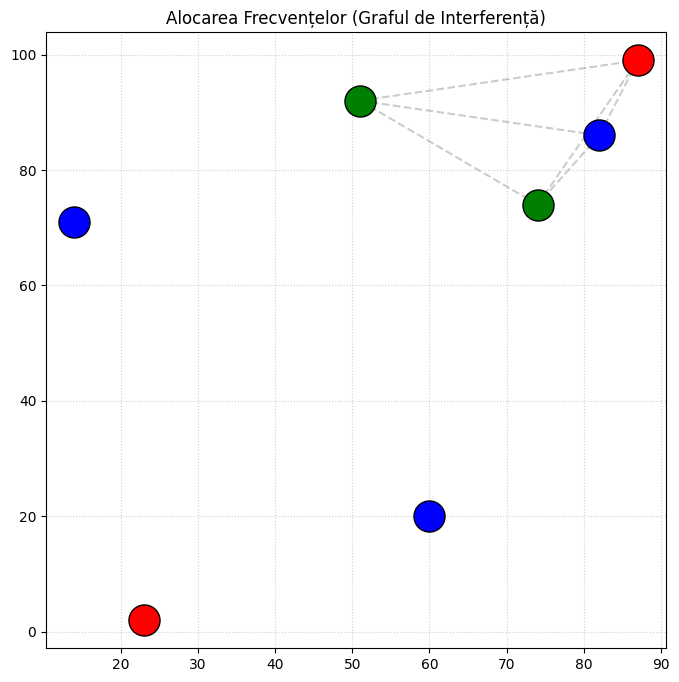

In [6]:
print("=== AI-ul rezolvă rețeaua acum ===")
model.eval()
eval_mcts = MCTS(env, args, model)
state = env.get_initial_state()

while True:
    action_probs = eval_mcts.search(state, current_num_searches=100)
    best_action = np.argmax(action_probs)
    
    state = env.get_next_state(state, best_action)
    value, done = env.get_value_and_terminated(state, best_action)
    
    if done:
        print(f"Alocare finalizată de AI! Frecvențe alocate: {state[1:]}")
        print(f"Recompensa obținută: {value:.3f} (1.0 = Fără nicio interferență)")
        draw_network(env, state)
        break

In [7]:

class ScaledFrequencyEnvironment(FrequencyEnvironment):
    def __init__(self, num_towers=30, num_frequencies=4, map_size=100):
        self.num_towers = num_towers
        self.num_frequencies = num_frequencies
        self.action_size = num_frequencies 
        
        # Generăm Harta cu mai multe turnuri
        self.tower_coords = np.random.randint(0, map_size, size=(num_towers, 2))
        self.interference_matrix = np.zeros((num_towers, num_towers), dtype=np.float32)
        
        for i in range(num_towers):
            for j in range(num_towers):
                if i != j:
                    dist = np.linalg.norm(self.tower_coords[i] - self.tower_coords[j])
                    # Reducem raza de interferență la 25
                    if dist < 25: 
                        self.interference_matrix[i, j] = 100.0 / (dist + 1.0)
                        
        self.max_possible_interference = np.sum(self.interference_matrix) / 2.0
        
    def __repr__(self):
        return "FrequencyAssignment_ScaledParallel"

def draw_scaled_network(env, state):
    frequencies = state[1:]
    colors = ['red', 'dodgerblue', 'limegreen', 'gold', 'purple', 'cyan']
    
    plt.figure(figsize=(10, 10))
    for i in range(env.num_towers):
        for j in range(i + 1, env.num_towers):
            if env.interference_matrix[i, j] > 0:
                plt.plot([env.tower_coords[i, 0], env.tower_coords[j, 0]], 
                         [env.tower_coords[i, 1], env.tower_coords[j, 1]], 
                         'k--', alpha=0.15)
                
    for i in range(env.num_towers):
        freq = int(frequencies[i])
        color = colors[freq] if freq != -1 else 'gray'
        plt.scatter(env.tower_coords[i, 0], env.tower_coords[i, 1], 
                    c=color, s=250, edgecolors='black', zorder=5)
        plt.text(env.tower_coords[i, 0], env.tower_coords[i, 1], f"T{i}", 
                 color='black', ha='center', va='center', fontweight='bold', fontsize=8)
        
    plt.title(f"Alocarea Frecvențelor - Scalat ({env.num_towers} Turnuri, {env.num_frequencies} Frecvențe)")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

In [8]:

np.random.seed(123) 
torch.manual_seed(123)

env_scaled = ScaledFrequencyEnvironment(num_towers=30, num_frequencies=4)

# RN de 256 neuroni AMD
model_scaled = FAP_MLP(env_scaled, num_hidden=256, device=device)
optimizer_scaled = torch.optim.Adam(model_scaled.parameters(), lr=0.001, weight_decay=1e-4)

args_scaled = {
    'C': 2.0,
    'num_searches': 120,         
    'num_searches_fast': 30,
    'prob_full_search': 0.25,
    'num_iterations': 4,          
    'num_selfPlay_iterations': 60,
    'num_parallel_games': 10,  
    'num_epochs': 4,
    'batch_size': 64,             
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

print("=== Începem antrenamentul AlphaZero la scară largă ===")
print("Placa video procesează batch-uri de stări. Așteaptă...")
az_agent_scaled = AlphaZeroParallel(model_scaled, optimizer_scaled, env_scaled, args_scaled)
az_agent_scaled.learn()
print("Antrenament finalizat!\n")

=== Începem antrenamentul AlphaZero la scară largă ===
Placa video procesează batch-uri de stări. Așteaptă...


Training Epochs 4: 100%|█████████████████████████| 4/4 [00:01<00:00,  2.07it/s]

Antrenament finalizat!



=== AI-ul rezolvă rețeaua cu 30 de turnuri ===

--- REZULTAT FINAL ---
Recompensa AI-ului: 0.506 (1.0 = Soluție Perfectă)


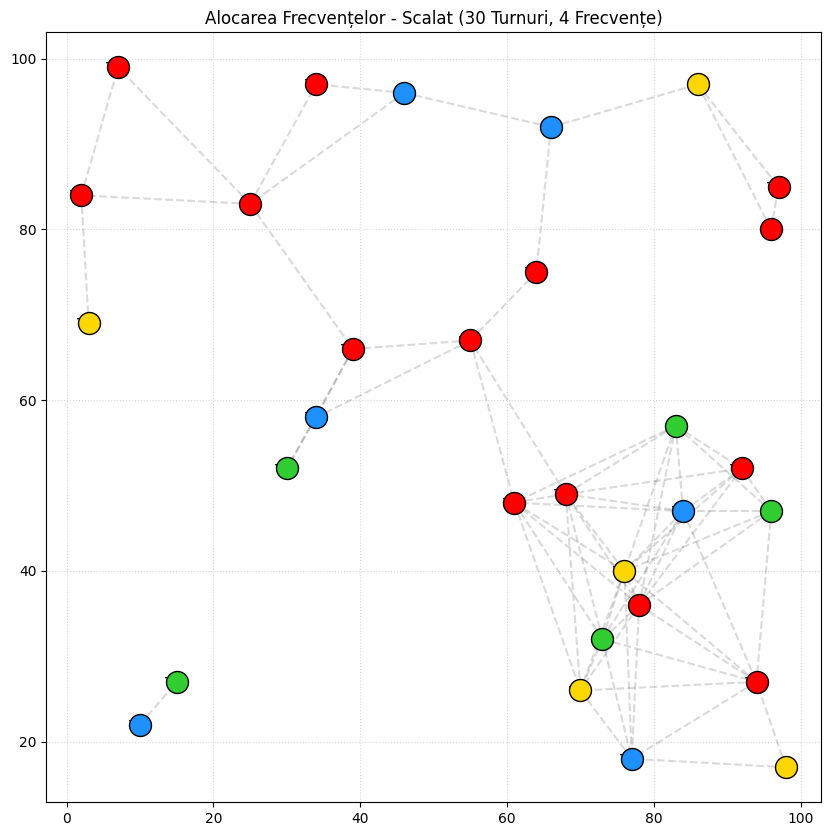

In [10]:
print("=== AI-ul rezolvă rețeaua cu 30 de turnuri ===")
model_scaled.eval()

eval_mcts_scaled = MCTS(env_scaled, args_scaled, model_scaled)
state = env_scaled.get_initial_state()

while True:
    action_probs = eval_mcts_scaled.search(state, current_num_searches=200)
    best_action = np.argmax(action_probs)
    
    state = env_scaled.get_next_state(state, best_action)
    value, done = env_scaled.get_value_and_terminated(state, best_action)
    
    if done:
        print("\n--- REZULTAT FINAL ---")
        print(f"Recompensa AI-ului: {value:.3f} (1.0 = Soluție Perfectă)")
        draw_scaled_network(env_scaled, state)
        break